### Mini Exploratory Data Analysis (EDA) on Titanic Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv("titanic.csv")

# Display first rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Inspect Dataset

In [3]:
print("Shape:", df.shape)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

df.info()

Shape: (891, 12)

Data Types
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non

### Step 3: Data Cleaning

#### Fill Missing Age with Mean

In [8]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

#### Fill Embarked with Mode

In [7]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

#### Drop Cabin Column

In [9]:
df.drop("Cabin", axis=1, inplace=True)

#### Verify Missing Values

In [10]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Step 4: Feature Engineering
#### Create Age Groups

In [12]:
bins = [0,12,19,35,60,100]

labels = ["Child","Teen","Young Adult","Adult","Senior"]

df["Age_Group"] = pd.cut(df["Age"],
                         bins=bins,
                         labels=labels)

#### Create Family Size

In [13]:
df["Family_Size"] = df["SibSp"] + df["Parch"]

### Step 5: Analysis
#### 1. Survival Rate by Age Group

In [14]:
age_survival = df.groupby("Age_Group")["Survived"].mean()*100

print(age_survival)

Age_Group
Child          57.971014
Teen           41.052632
Young Adult    35.294118
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


C:\Users\prath\AppData\Local\Temp\ipykernel_27312\2586098121.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("Age_Group")["Survived"].mean()*100


#### 2. Survival Rate by Embarkation Port

In [15]:
embark_survival = df.groupby("Embarked")["Survived"].mean()*100

print(embark_survival)

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


#### Survival Rate by Family Size



In [16]:
family_survival = df.groupby("Family_Size")["Survived"].mean()*100

print(family_survival)

Family_Size
0     30.353818
1     55.279503
2     57.843137
3     72.413793
4     20.000000
5     13.636364
6     33.333333
7      0.000000
10     0.000000
Name: Survived, dtype: float64


### Step 6: Visualizations
#### 1. Age Distribution Histogram

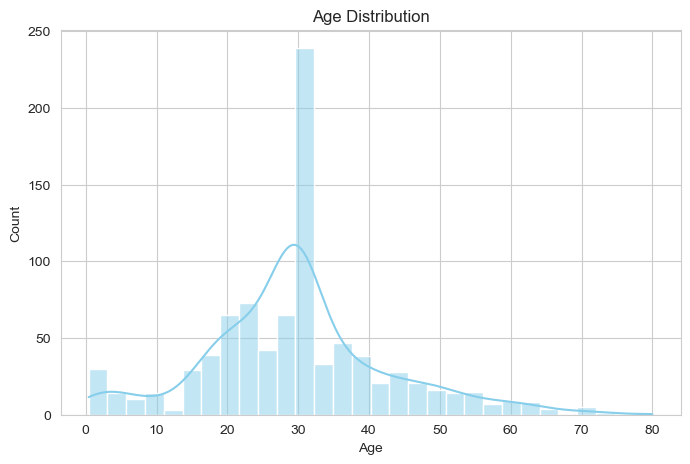

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"],
             bins=30,
             kde=True,
             color="skyblue")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

#### 2. Correlation Heatmap

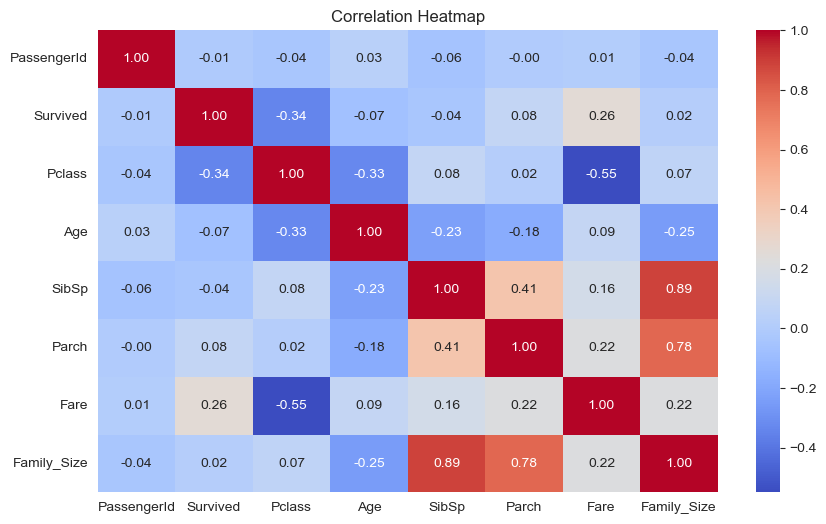

In [18]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

#### 3. Survival by Family Size

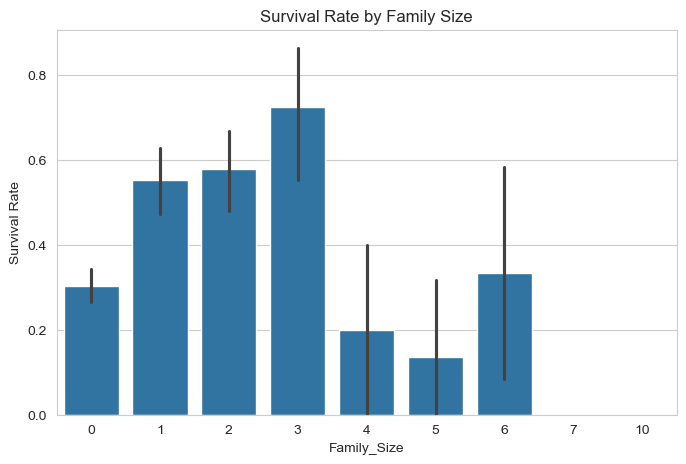

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(x="Family_Size",
            y="Survived",
            data=df,
            estimator=np.mean)

plt.title("Survival Rate by Family Size")
plt.ylabel("Survival Rate")

plt.show()

#### 4. Survival by Age Group

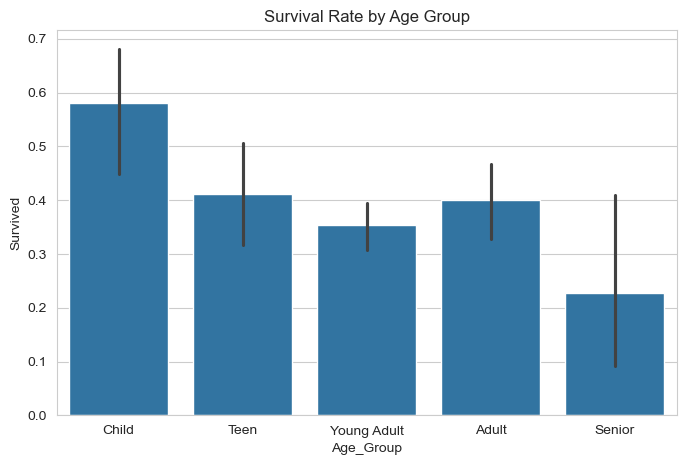

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(x="Age_Group",
            y="Survived",
            data=df,
            estimator=np.mean)

plt.title("Survival Rate by Age Group")

plt.show()

#### 5. Survival by Embarkation Port

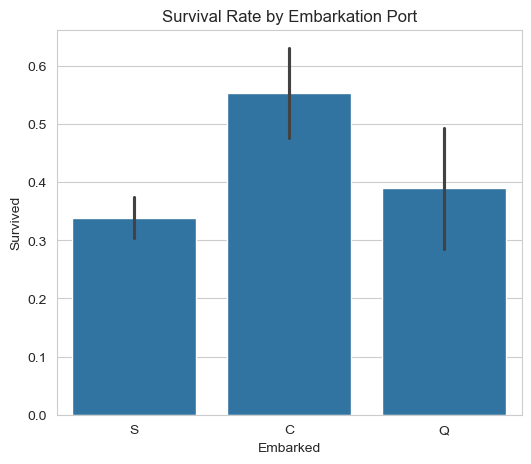

In [21]:
plt.figure(figsize=(6,5))

sns.barplot(x="Embarked",
            y="Survived",
            data=df,
            estimator=np.mean)

plt.title("Survival Rate by Embarkation Port")

plt.show()

#### 6. Survival by Passenger Class

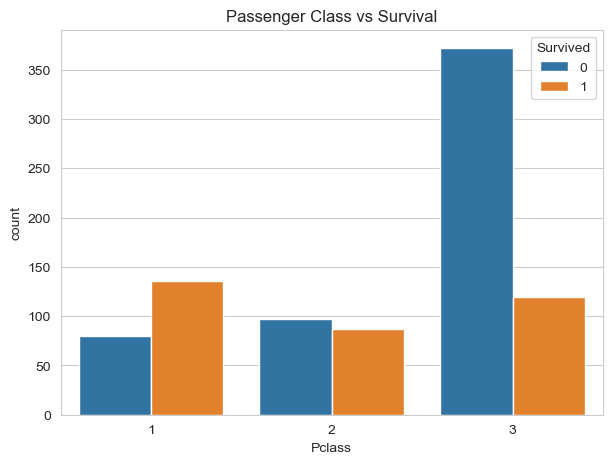

In [22]:
plt.figure(figsize=(7,5))

sns.countplot(x="Pclass",
              hue="Survived",
              data=df)

plt.title("Passenger Class vs Survival")

plt.show()

#### 7. Survival by Gender

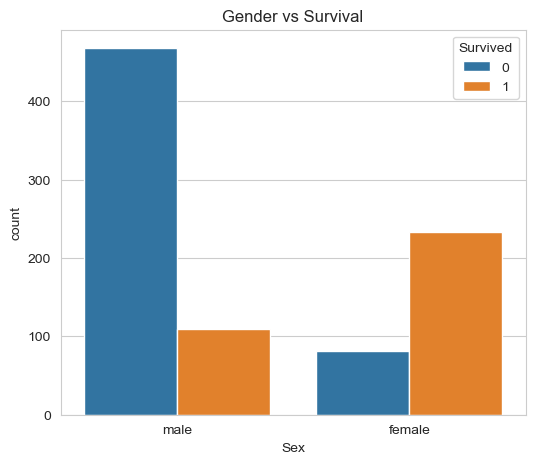

In [23]:
plt.figure(figsize=(6,5))

sns.countplot(x="Sex",
              hue="Survived",
              data=df)

plt.title("Gender vs Survival")

plt.show()

In [ ]:
### Step 7: Insights
